In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class BatchGD:

    def __init__(self, learning_rate=0.0001, epochs=10000, tolerance=0.001):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance

        self.theta_0 = None
        self.theta_1 = None
        self.losses = []

    def fit(self, X, y):
        X = (X - np.mean(X)) / np.std(X)

        X = X.reshape(1, -1)
        y = y.reshape(-1, 1)

        _, m = X.shape

        self.theta_0 = np.random.randn(1,1)
        self.theta_1 = np.random.randn(1,1)

        epoch = 1
        loss = 1

        while epoch < self.epochs and loss > self.tolerance:
            y_hat = self.theta_0 * X + self.theta_1

            loss = 0.5 * np.mean((y_hat.T - y) ** 2)

            self.losses.append(loss)

            d_theta_0 = (1/m) * np.dot(X, (y_hat.T - y))
            d_theta_1 = (1/m) * np.sum(y_hat.T - y)

            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1

            epoch += 1

    def predict(self, X):
        X = (X - np.mean(X)) / np.std(X)
        X = X.reshape(1,-1)

        predictions = self.theta_0 * X + self.theta_1

        return predictions.T

    def plot_loss(self):

        plt.plot(self.losses)
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Gradient Descent Loss Curve")
        plt.show()

    def parameters(self):
        return self.theta_0, self.theta_1

In [4]:
import pandas as pd
import matplotlib.pyplot as plt 

df = pd.read_csv("c:/Users/DS-31/Desktop/Suja Meow ^-^/Meowchine Learning/Synthetic.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

x = df.iloc[:, 0].values
y = df.iloc[:, 1].values

x.shape, y.shape

x = (x - np.mean(x)) / np.std(x)

x = x.reshape(1, -1)
y = y.reshape(-1, 1)

x.shape, y.shape

noOfFeatures, m = x.shape

Text(0, 0.5, 'Loss')

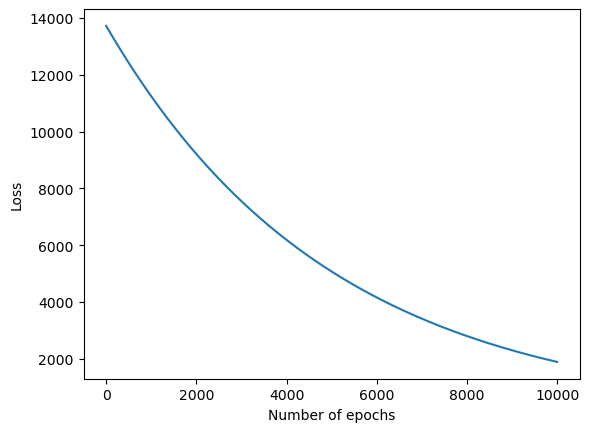

In [5]:
model = BatchGD(learning_rate=0.0001, epochs=10000, tolerance=0.001)
model.fit(x, y)

plt.plot(model.losses)
plt.xlabel("Number of epochs")
plt.ylabel("Loss")


## OOP STOCHASTIC GD

In [12]:
import numpy as np
import matplotlib.pyplot as plt

class StochasticGD:

    def __init__(self, learning_rate=0.001, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.theta_0 = None      
        self.theta_1 = None      
        self.losses = []
        self.mean = None
        self.std = None

    def fit(self, x, y):

        self.mean = np.mean(x)
        self.std = np.std(x)
        x = (x - self.mean) / self.std

        x = x.reshape(-1, 1)
        y = y.reshape(-1, 1)

        m = len(x)

        self.theta_0 = np.random.randn()
        self.theta_1 = np.random.randn()

        for epoch in range(self.epochs):

            indices = np.random.permutation(m)
            x_shuffled = x[indices]
            y_shuffled = y[indices]

            total_loss = 0

            for i in range(m):

                xi = x_shuffled[i]
                yi = y_shuffled[i]

                y_hat = self.theta_0 * xi + self.theta_1

                error = y_hat - yi
                total_loss += 0.5 * error**2

                d_theta_0 = error * xi
                d_theta_1 = error

                self.theta_0 -= self.learning_rate * d_theta_0.item()
                self.theta_1 -= self.learning_rate * d_theta_1.item()

            self.losses.append(total_loss.item() / m)

    def predict(self, X):

        X = (X - self.mean) / self.std
        X = X.reshape(-1,1)

        return self.theta_0 * X + self.theta_1

    def plot_loss(self):

        plt.plot(self.losses)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("SGD Loss Curve")
        plt.show()

    def parameters(self):
        return self.theta_0, self.theta_1

In [13]:
df = pd.read_csv("c:/Users/DS-31/Desktop/Suja Meow ^-^/Meowchine Learning/Synthetic.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

x = df.iloc[:, 0].values
y = df.iloc[:, 1].values

x.shape, y.shape

x = (x - np.mean(x)) / np.std(x)

x = x.reshape(1, -1)
y = y.reshape(-1, 1)

x.shape, y.shape

noOfFeatures, m = x.shape

Text(0, 0.5, 'Loss')

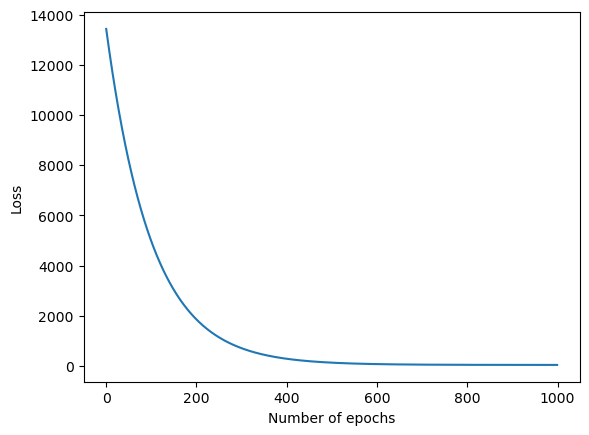

In [24]:
model1 = StochasticGD(learning_rate=0.0001, epochs=1000)
model1.fit(x, y)

plt.plot(model1.losses)
plt.xlabel("Number of epochs")
plt.ylabel("Loss")


## OOP MINI BATCH

In [28]:
import numpy as np
import matplotlib.pyplot as plt

class MiniGD:

    def __init__(self, learning_rate=0.001, epochs=100, batch_size=32):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size

        self.theta_0 = None
        self.theta_1 = None

        self.mean = None
        self.std = None

        self.losses = []

    def fit(self, X, y):

        self.mean = np.mean(X)
        self.std = np.std(X)

        X = (X - self.mean) / self.std

        X = X.reshape(-1,1)
        y = y.reshape(-1,1)

        m = len(X)

        self.theta_0 = np.random.randn()
        self.theta_1 = np.random.randn()

        for epoch in range(self.epochs):

            indices = np.random.permutation(m)
            X = X[indices]
            y = y[indices]

            total_loss = 0

            for start in range(0, m, self.batch_size):

                end = start + self.batch_size

                X_batch = X[start:end]
                y_batch = y[start:end]

                y_hat = self.theta_0 * X_batch + self.theta_1

                error = y_hat - y_batch

                batch_loss = 0.5 * np.mean(error**2)
                total_loss += batch_loss

                d_theta_0 = np.mean(error * X_batch)
                d_theta_1 = np.mean(error)

                self.theta_0 -= self.learning_rate * d_theta_0
                self.theta_1 -= self.learning_rate * d_theta_1

            self.losses.append(total_loss)

    def predict(self, x):

        x = (x - self.mean) / self.std
        x = x.reshape(-1,1)

        return self.theta_0 * x + self.theta_1

    def plot_loss(self):

        plt.plot(self.losses)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Mini-Batch Gradient Descent")
        plt.show()

    def parameters(self):

        return self.theta_0, self.theta_1

[[53.70372425]] [[89.21904709]]


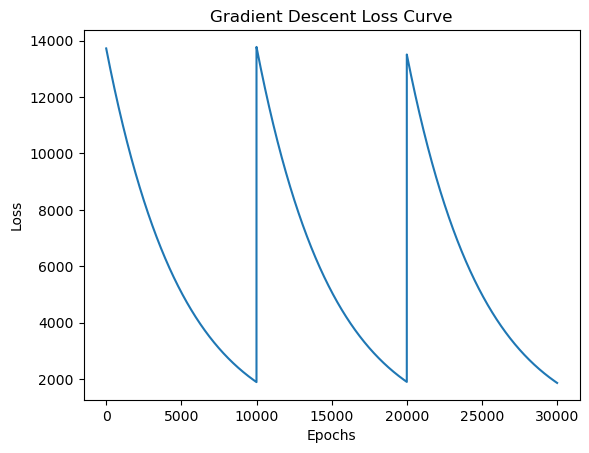

In [ ]:
model2 = MiniGD(learning_rate=0.001,epochs=100,batch_size=48)

model.fit(x, y)

theta0, theta1 = model.parameters()

print(theta0, theta1)

pred = model.predict(x)

model.plot_loss()